# Sesión 02 — Modelos de Clasificación (Wine Quality): Ejercicios 1 y 2
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  
**Estudiante:** ESPINOZA INGA DEYSI KAREN

https://github.com/deysiespinoza/Invgenieria-del-conocimiento_tareas

---

## Objetivo
Implementar y comparar cuatro modelos de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Wine Quality (tinto)** de UCI y resolver los ejercicios propuestos al final de la sesión:

| Sección | Contenido |
|---|---|
| 1–10 | Sesión base (binaria: calidad ≥ 7) |
| **11** | **Ejercicio 1 — `GridSearchCV` para SVM** |
| **12** | **Ejercicio 2 — Clasificación multiclase (calidad 3–8)** |
| 13 | Conclusiones |

> El **Ejercicio 3** (dataset propio) EN EL OTRO ARCHIVO.



---
## 1. Configuración del entorno

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    balanced_accuracy_score, precision_recall_fscore_support
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

**Wine Quality (Red)** de UCI: 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8). Para la parte binaria:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

In [2]:
import os
LOCAL = 'winequality-red.csv'
URLS = ['https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',
        'https://raw.githubusercontent.com/shrikant-temburwar/Wine-Quality-Dataset/master/winequality-red.csv']

def load_wine():
    if os.path.exists(LOCAL):
        return pd.read_csv(LOCAL, sep=';'), 'archivo local'
    for u in URLS:
        try:
            d = pd.read_csv(u, sep=';')
            if d.shape[1] == 12:
                return d, u
        except Exception as e:
            print('No disponible:', u.split('/')[2])
    raise RuntimeError('Sube winequality-red.csv al entorno de Colab.')

df, origen = load_wine()
print(f'Dataset cargado ({origen}): {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado (archivo local): 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


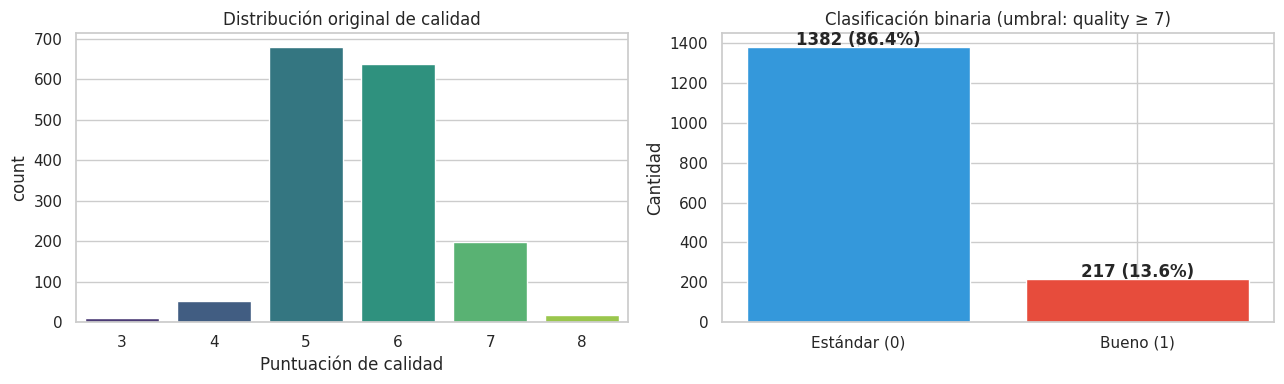


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [3]:
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

df['quality_label'] = (df['quality'] >= 7).astype(int)
counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values, color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')
plt.tight_layout()
plt.show()
print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [4]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])
comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


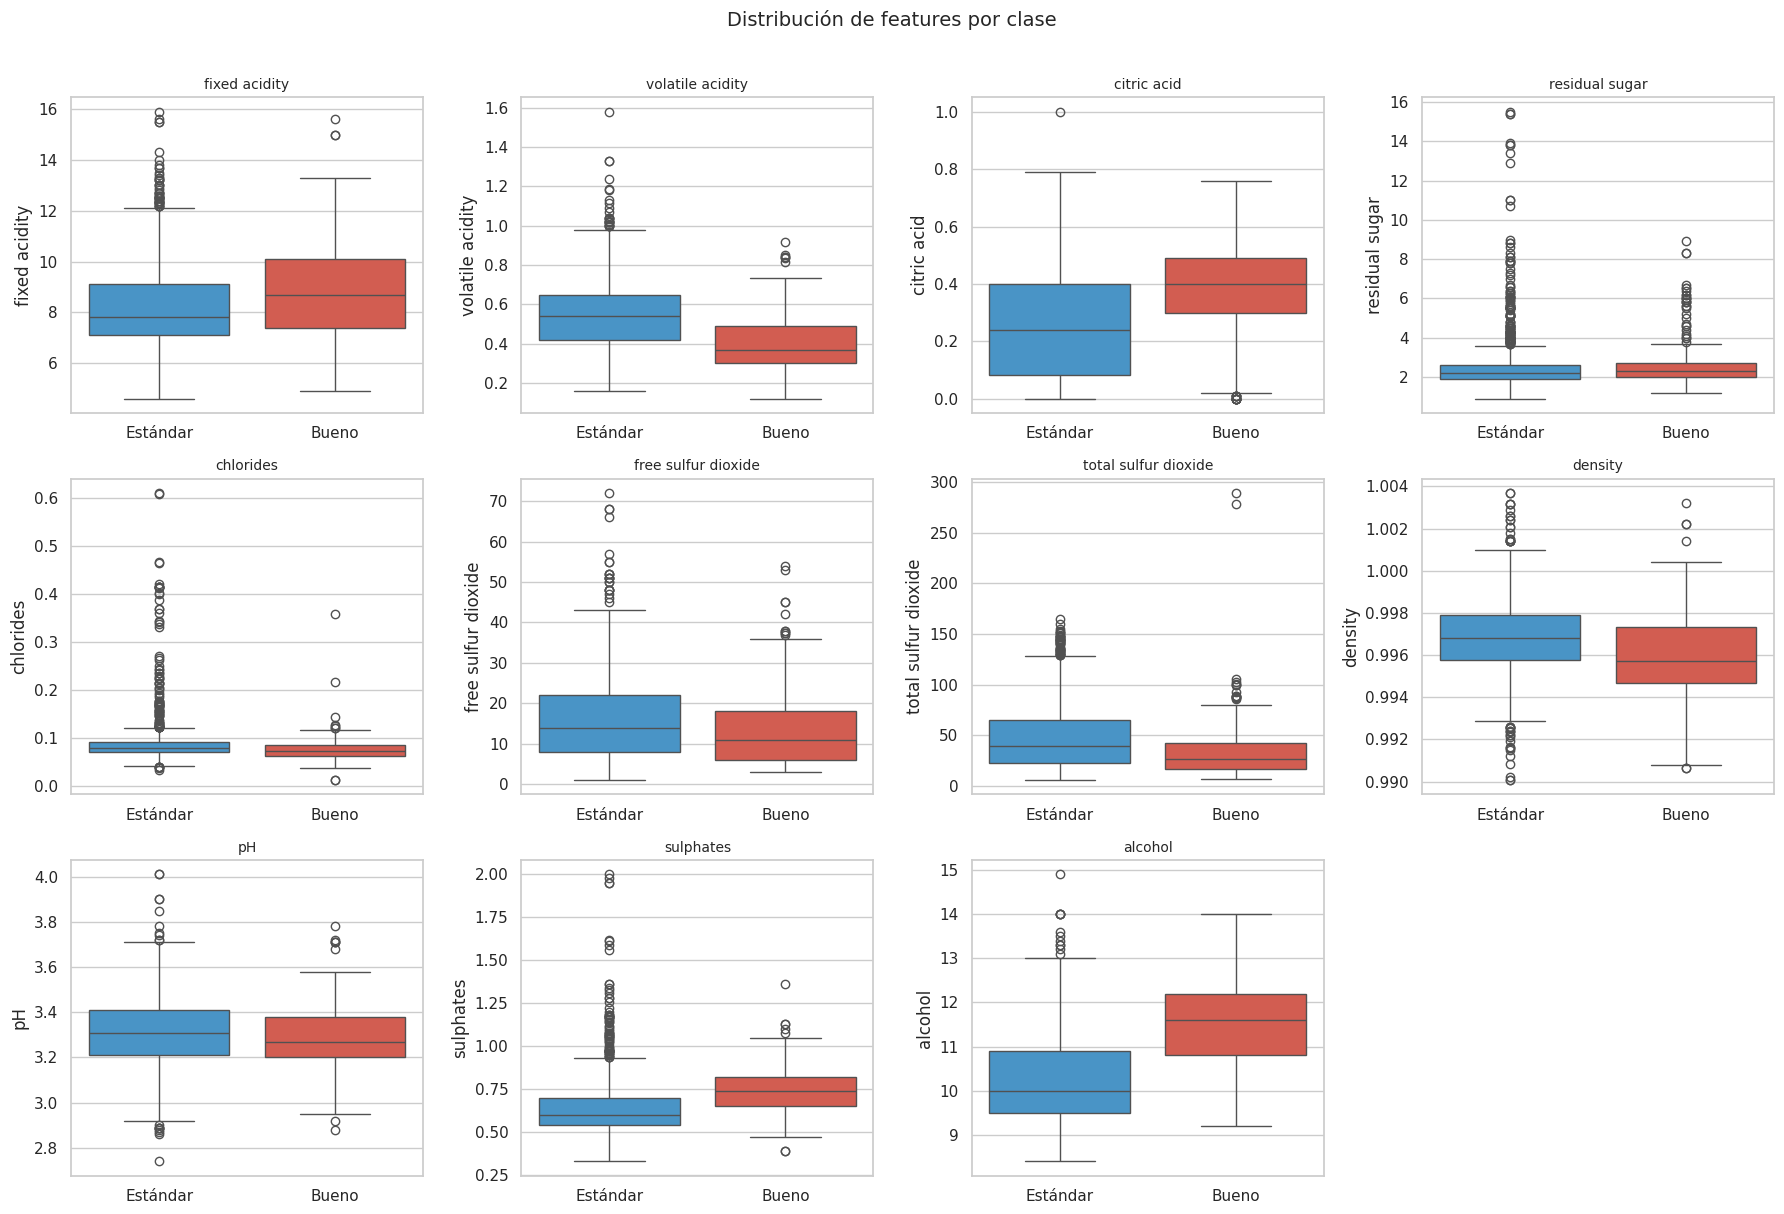

In [5]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticks([0, 1]); axes[i].set_xticklabels(['Estándar', 'Bueno'])
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

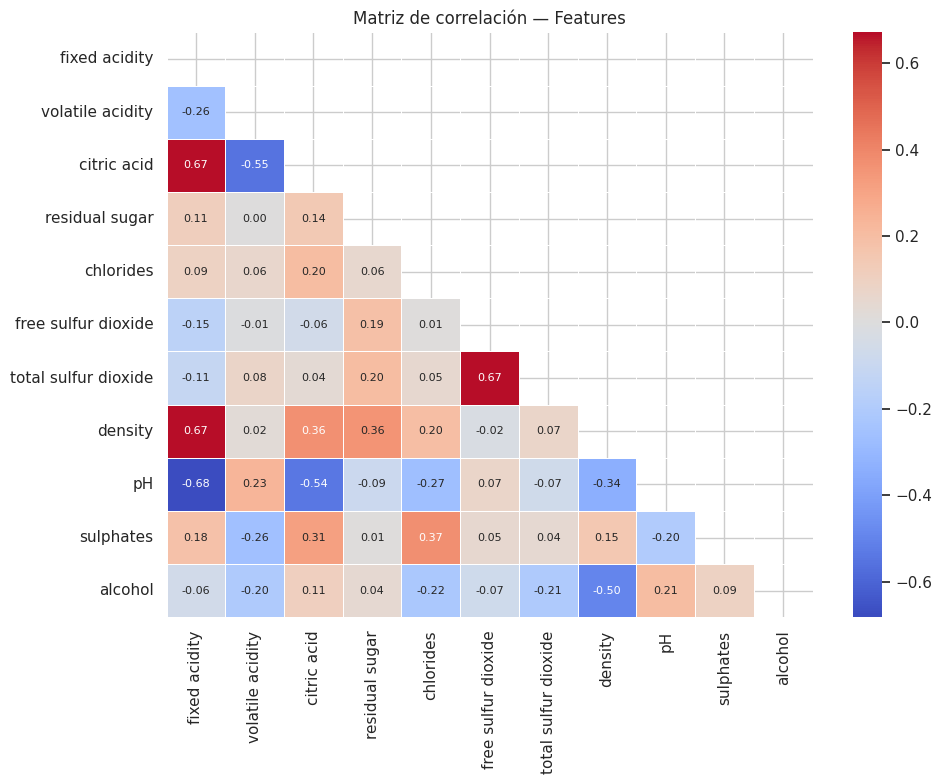

In [6]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [7]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [8]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('=' * 50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')
print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística
**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [9]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


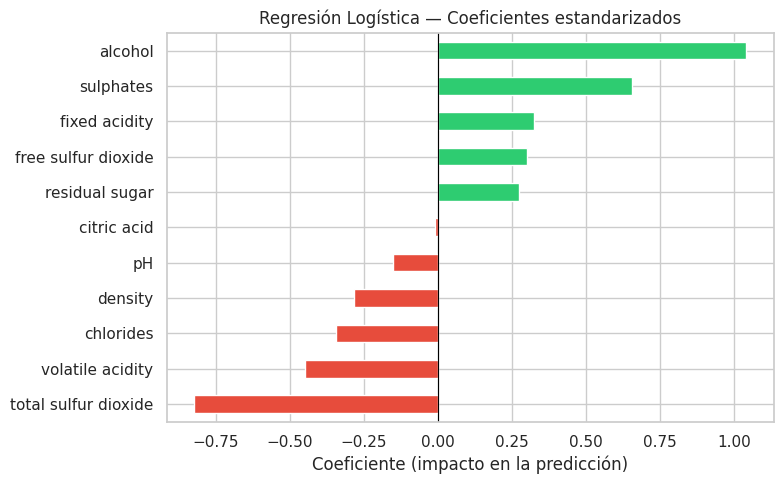


Interpretación: un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [10]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(pipe_lr.named_steps['clf'].coef_[0], index=features).sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
coefs.plot(kind='barh', ax=ax, color=['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values])
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print('\nInterpretación: un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión
**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [11]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                                   class_weight='balanced', random_state=RANDOM_STATE))])
scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


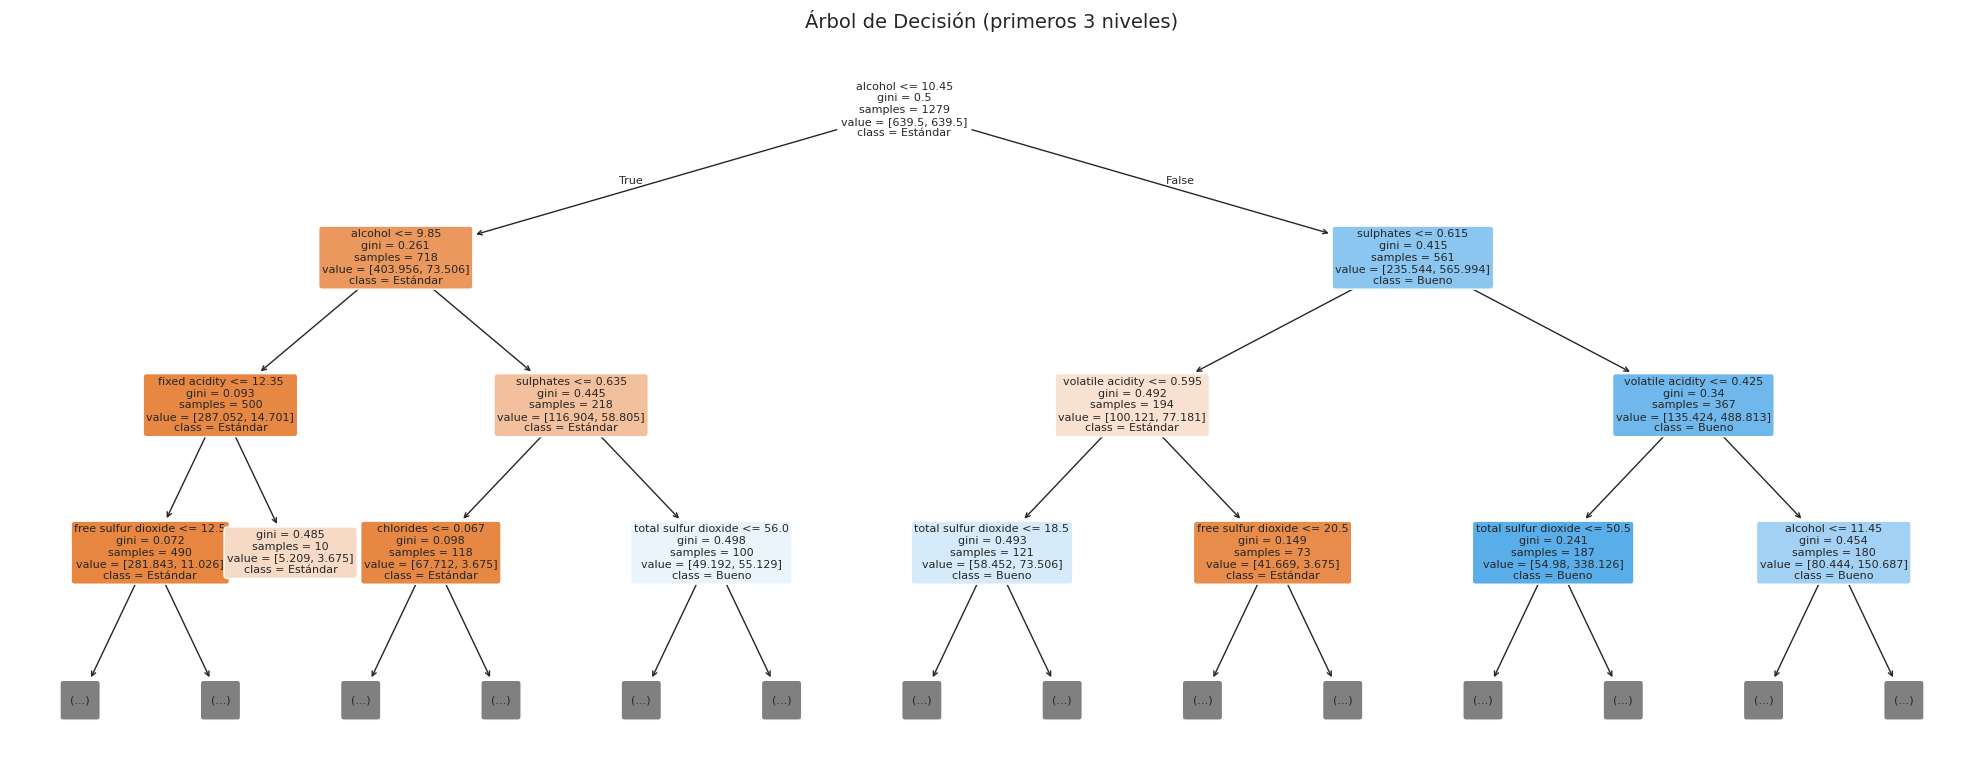

In [12]:
# 6.2  Visualización del árbol (3 niveles)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(pipe_dt.named_steps['clf'], feature_names=list(features), class_names=['Estándar', 'Bueno'],
          filled=True, rounded=True, fontsize=8, ax=ax, max_depth=3)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

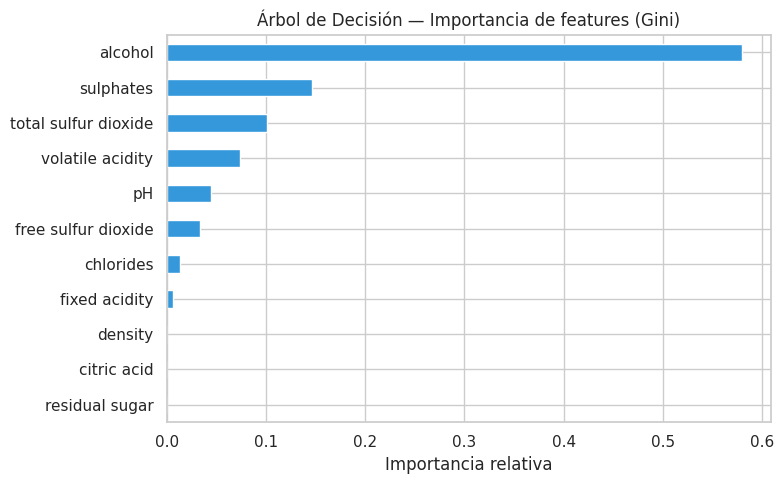

In [13]:
# 6.3  Importancia de features (Gini)
importances = pd.Series(pipe_dt.named_steps['clf'].feature_importances_, index=features).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

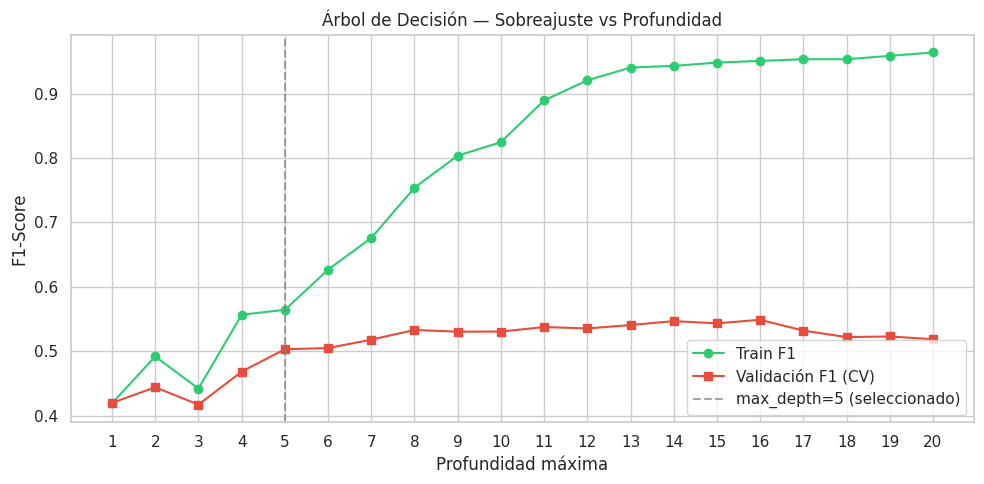

Observación: cuando la brecha entre train y validación crece, el modelo está sobreajustando.


In [14]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores, val_scores = [], []
for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    val_scores.append(cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1').mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima'); ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend(); ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()
print('Observación: cuando la brecha entre train y validación crece, el modelo está sobreajustando.')

---
## 7. Modelo 3 — Support Vector Machine (SVM)
**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con kernels puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [15]:
# 7.1  Comparación de kernels
svm_results = {}
for kernel in ['linear', 'rbf', 'poly']:
    p = Pipeline([('scaler', StandardScaler()),
                  ('clf', SVC(kernel=kernel, class_weight='balanced', random_state=RANDOM_STATE, probability=True))])
    svm_results[kernel] = cross_val_score(p, X_train, y_train, cv=cv, scoring='f1')
    print(f'SVM ({kernel:6s}) — F1 CV: {svm_results[kernel].mean():.4f} ± {svm_results[kernel].std():.4f}')
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237


SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427


SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [16]:
# 7.2  Entrenamiento con el mejor kernel (SVM base de la sesión)
pipe_svm = Pipeline([('scaler', StandardScaler()),
                     ('clf', SVC(kernel=best_kernel, class_weight='balanced', random_state=RANDOM_STATE, probability=True))])
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [17]:
# 7.3  Impacto de la estandarización en SVM
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced', random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')
print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)
**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. K controla el trade-off sesgo-varianza.

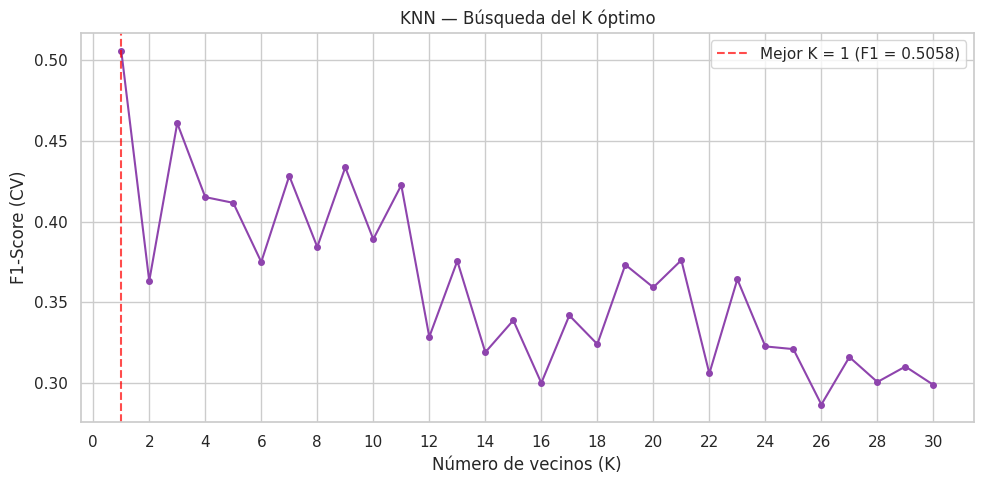

K óptimo: 1


In [18]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []
for k in k_range:
    p = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=k))])
    k_scores.append(cross_val_score(p, X_train, y_train, cv=cv, scoring='f1').mean())
best_k = k_range[int(np.argmax(k_scores))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)'); ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend(); ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()
print(f'K óptimo: {best_k}')

In [19]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=best_k))])
scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')
pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [20]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn),
}
summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({'Modelo': name,
                    'F1 CV (mean)': f'{cv_scores.mean():.4f}', 'F1 CV (std)': f'{cv_scores.std():.4f}',
                    'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
                    'F1 Test': f'{f1_score(y_test, y_pred):.4f}'})
summary_df = pd.DataFrame(summary)
print('=' * 80); print('COMPARACIÓN DE MODELOS'); print('=' * 80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


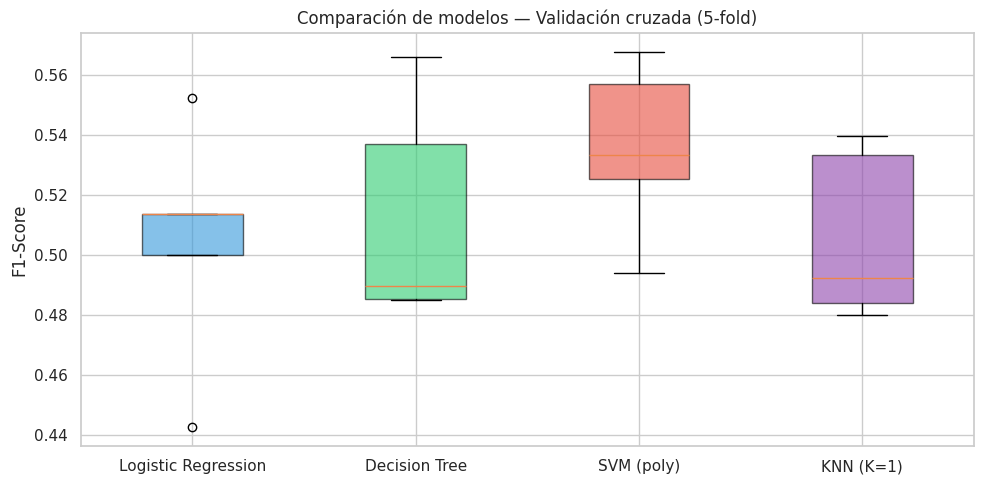

In [21]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot([scores_lr, scores_dt, scores_svm, scores_knn], patch_artist=True)
ax.set_xticklabels(list(models.keys()))
for patch, color in zip(bp['boxes'], ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

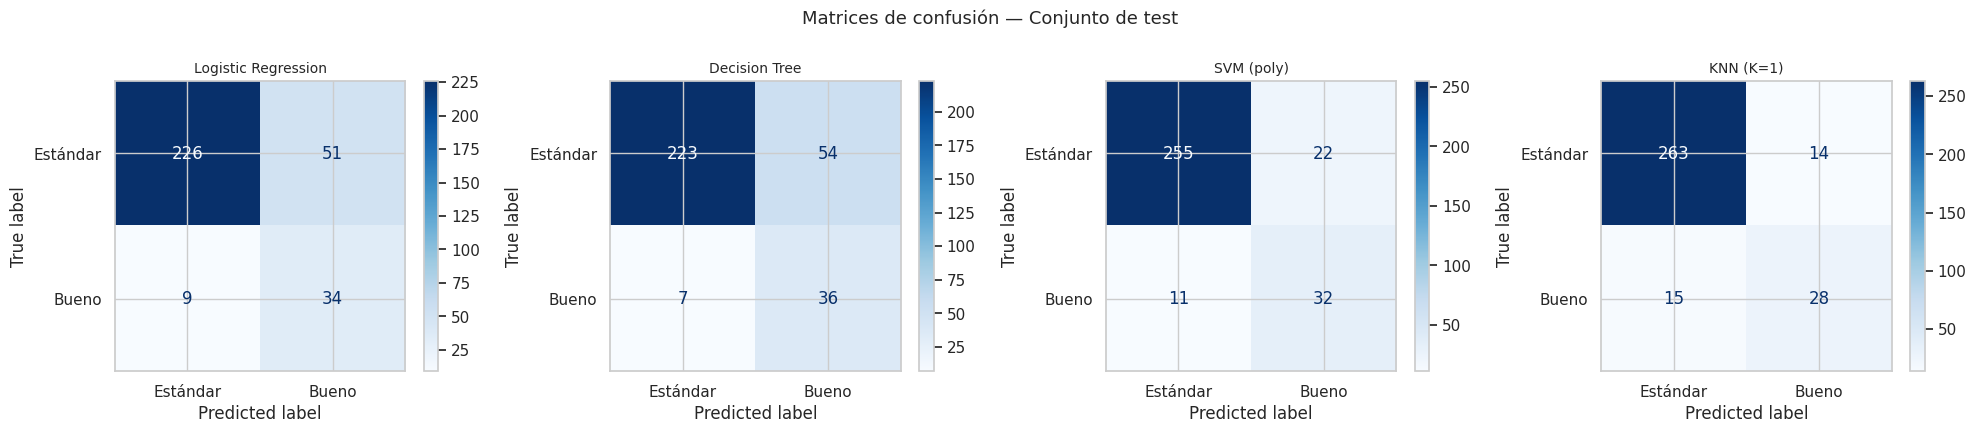

In [22]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Estándar', 'Bueno'], cmap='Blues', ax=ax)
    ax.set_title(name, fontsize=10)
fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

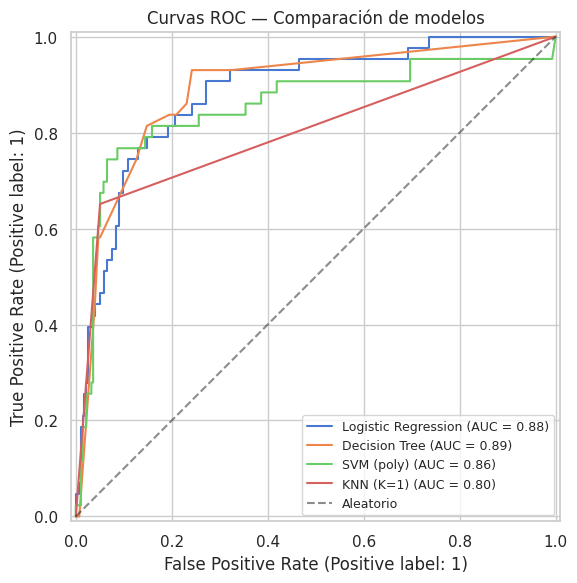

In [23]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))
for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]
print(f'\nMejor modelo (por F1 CV): {best_model_name}')
print('=' * 60)
print(classification_report(y_test, best_pred, target_names=['Estándar', 'Bueno']))


Mejor modelo (por F1 CV): SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



### Lectura de la sesión base (binaria: calidad ≥ 7)

- **SVM (kernel `poly`) es el mejor por F1 en CV** (0.536 ± 0.026) y en test (F1 0.660; para la clase *Bueno*: Precision 0.59, Recall 0.74). Sin embargo, **las diferencias en CV entre los cuatro modelos (0.50–0.54) son menores que una desviación estándar entre folds (≈ 0.03–0.04)**: no hay un ganador estadísticamente claro.
- **La estandarización es decisiva para la SVM:** sin `StandardScaler` el F1 cae de 0.536 a 0.283 (**−25 puntos**).
- **Accuracy vs F1:** con 13.6 % de vinos buenos, predecir siempre "Estándar" da accuracy 0.866. La Regresión Logística y el Árbol (entrenados con `class_weight='balanced'`) obtienen accuracy 0.81 —**por debajo de esa referencia**— porque sacrifican accuracy para detectar más vinos buenos; por eso el F1 de la clase minoritaria es la métrica informativa aquí.
- **KNN eligió K = 1 (vecino más cercano):** es el extremo de máxima varianza. Como se verifica en la sección 12.9, el dataset contiene **240 filas duplicadas (15 %)** y ≈ 24 % de las filas de test tienen una copia exacta en train, lo que favorece a un modelo que memoriza. 

---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable, maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción; sensible a escala y dimensionalidad | Datasets pequeños-medianos; frontera irregular |

---
## 11. Ejercicio 1 — GridSearchCV para SVM

**Enunciado:** búsqueda de hiperparámetros para SVM con `GridSearchCV` y la grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reportar los mejores hiperparámetros, el F1-score obtenido y **comparar contra el SVM base de la sesión**.



In [25]:
# 11.1  Búsqueda en malla
pipe_grid = Pipeline([('scaler', StandardScaler()),
                      ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))])
param_grid = {
    'clf__C':      [0.1, 1, 10, 100],
    'clf__gamma':  ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly'],
}
gs = GridSearchCV(pipe_grid, param_grid, cv=cv, scoring='f1', n_jobs=-1, refit=True, return_train_score=True)
t0 = time.time()
gs.fit(X_train, y_train)
print(f'Búsqueda completada en {time.time() - t0:.1f} s  ({len(gs.cv_results_["params"])} combinaciones)')
print('\nMejores hiperparámetros:')
for k, v in gs.best_params_.items():
    print(f'  {k.replace("clf__", ""):8s}: {v}')
print(f'\nMejor F1 (CV): {gs.best_score_:.4f}')

Búsqueda completada en 10.6 s  (32 combinaciones)

Mejores hiperparámetros:
  C       : 10
  gamma   : 0.1
  kernel  : rbf

Mejor F1 (CV): 0.5450


In [26]:
# 11.2  Top 10 combinaciones
res = pd.DataFrame(gs.cv_results_)
top = (res.sort_values('rank_test_score')
          .loc[:, ['rank_test_score', 'param_clf__kernel', 'param_clf__C', 'param_clf__gamma',
                   'mean_test_score', 'std_test_score', 'mean_train_score']]
          .head(10).rename(columns={'rank_test_score': 'Rank', 'param_clf__kernel': 'kernel', 'param_clf__C': 'C',
                                    'param_clf__gamma': 'gamma', 'mean_test_score': 'F1 CV',
                                    'std_test_score': 'σ F1 CV', 'mean_train_score': 'F1 train'}))
top['Brecha train–CV'] = top['F1 train'] - top['F1 CV']
print('Top 10 combinaciones (por F1 CV):')
top.round(4).reset_index(drop=True)

Top 10 combinaciones (por F1 CV):


,Rank,kernel,C,gamma,F1 CV,σ F1 CV,F1 train,Brecha train–CV
0,1,rbf,10.0,0.1,0.5450,0.0413,0.7848,0.2398
1,2,poly,0.1,0.1,0.5406,0.0445,0.5848,0.0441
2,2,poly,100.0,0.01,0.5406,0.0445,0.5848,0.0441
3,4,poly,1.0,scale,0.5355,0.0258,0.6545,0.1190
4,4,poly,1.0,auto,0.5355,0.0258,0.6545,0.1190
5,6,rbf,10.0,auto,0.5343,0.0397,0.7688,0.2346
6,6,rbf,10.0,scale,0.5343,0.0397,0.7688,0.2346
7,8,poly,10.0,0.1,0.5313,0.0239,0.7378,0.2064
8,9,poly,1.0,0.1,0.5288,0.0296,0.6641,0.1353
9,10,poly,0.1,auto,0.5279,0.0448,0.5817,0.0537


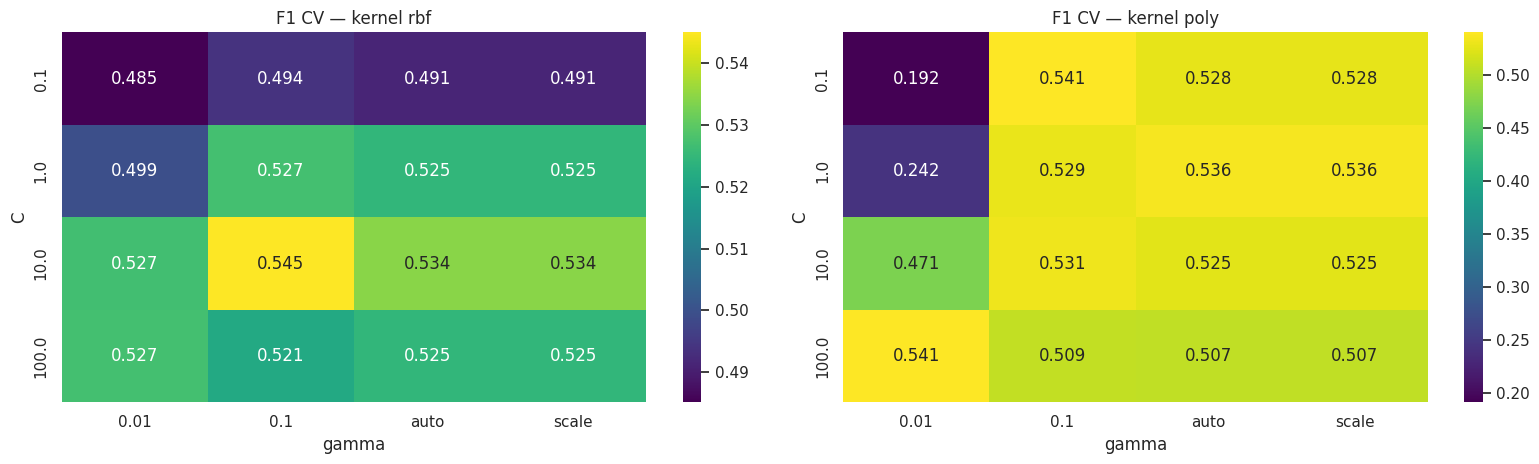

Nota: con datos estandarizados Var(X) = 1, así que 'scale' = 1/(n_features·Var(X)) = 1/11 y 'auto' = 1/n_features = 1/11.
      Ambos valen ≈ 0.091 y producen resultados IDÉNTICOS (por eso empatan en el ranking); además están muy cerca de gamma = 0.1.


In [27]:
# 11.3  Mapas de calor C × gamma por kernel
fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
for ax, kern in zip(axes, ['rbf', 'poly']):
    sub = res[res['param_clf__kernel'] == kern]
    piv = sub.pivot_table(index='param_clf__C', columns='param_clf__gamma', values='mean_test_score', aggfunc='mean')
    sns.heatmap(piv, annot=True, fmt='.3f', cmap='viridis', ax=ax)
    ax.set_title(f'F1 CV — kernel {kern}'); ax.set_xlabel('gamma'); ax.set_ylabel('C')
plt.tight_layout()
plt.show()
print("Nota: con datos estandarizados Var(X) = 1, así que 'scale' = 1/(n_features·Var(X)) = 1/11 y 'auto' = 1/n_features = 1/11.")
print("      Ambos valen ≈ 0.091 y producen resultados IDÉNTICOS (por eso empatan en el ranking); además están muy cerca de gamma = 0.1.")

In [28]:
# 11.4  Comparación SVM base vs SVM optimizado
svm_opt = gs.best_estimator_
svm_base = pipe_svm   # SVM de la sesión (mejor kernel, C=1, gamma='scale')

def full_metrics(model, name):
    yp = model.predict(X_test)
    return {'Modelo': name,
            'Accuracy': accuracy_score(y_test, yp), 'Precision': precision_score(y_test, yp),
            'Recall': recall_score(y_test, yp), 'F1 test': f1_score(y_test, yp),
            'AUC': roc_auc_score(y_test, model.decision_function(X_test)),
            'FN': int(((yp == 0) & (y_test == 1)).sum()), 'FP': int(((yp == 1) & (y_test == 0)).sum())}

cmp = pd.DataFrame([full_metrics(svm_base, f'SVM base ({best_kernel}, C=1, gamma=scale)'),
                    full_metrics(svm_opt, 'SVM optimizado (GridSearchCV)')]).set_index('Modelo')
cmp['F1 CV'] = [scores_svm.mean(), gs.best_score_]
print('=== SVM base vs SVM optimizado ===')
display(cmp.round(4))
print(f'\nΔ F1 CV   = {(gs.best_score_ - scores_svm.mean()) * 100:+.2f} pts')
print(f'Δ F1 test = {(cmp["F1 test"].iloc[1] - cmp["F1 test"].iloc[0]) * 100:+.2f} pts')

=== SVM base vs SVM optimizado ===


,Accuracy,Precision,Recall,F1 test,AUC,FN,FP,F1 CV
Modelo,,,,,,,,
"SVM base (poly, C=1, gamma=scale)",0.8969,0.5926,0.7442,0.6598,0.8549,11,22,0.5355
SVM optimizado (GridSearchCV),0.8781,0.5303,0.8140,0.6422,0.8819,8,31,0.5450



Δ F1 CV   = +0.95 pts
Δ F1 test = -1.76 pts


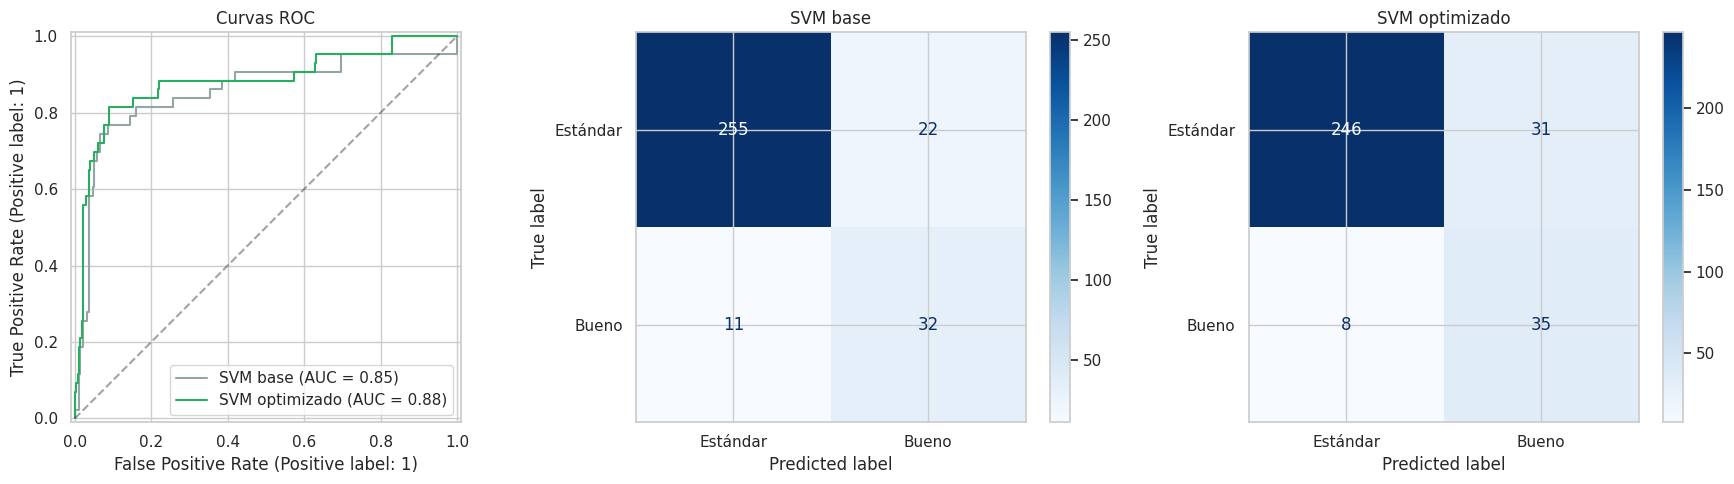

In [29]:
# 11.5  Curvas ROC y matrices de confusión: base vs optimizado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for m, nm, col in [(svm_base, 'SVM base', '#95a5a6'), (svm_opt, 'SVM optimizado', '#27ae60')]:
    RocCurveDisplay.from_predictions(y_test, m.decision_function(X_test), ax=axes[0], name=nm, color=col)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4); axes[0].set_title('Curvas ROC'); axes[0].legend(loc='lower right')
for ax, m, nm in zip(axes[1:], [svm_base, svm_opt], ['SVM base', 'SVM optimizado']):
    ConfusionMatrixDisplay.from_predictions(y_test, m.predict(X_test), display_labels=['Estándar', 'Bueno'], cmap='Blues', ax=ax)
    ax.set_title(nm)
plt.tight_layout()
plt.show()

In [30]:
# 11.6  ¿La mejora es real? Comparación pareada por fold (mismos 5 folds)
sc_base = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
sc_opt = cross_val_score(svm_opt, X_train, y_train, cv=cv, scoring='f1')
d = sc_opt - sc_base
print('F1 por fold:')
print(pd.DataFrame({'base': sc_base, 'optimizado': sc_opt, 'diferencia': d}).round(4).T.to_string())
print(f'\nDiferencia media = {d.mean():+.4f}   |   desv. entre folds = {d.std():.4f}')
print(f'Folds en que el optimizado mejora: {(d > 0).sum()} de {len(d)}')
print('\n⚠ Sesgo optimista: gs.best_score_ se usó para ELEGIR la configuración, por lo que sobrestima el rendimiento real.')
print('  El F1 en test (datos no usados en la búsqueda) es la estimación honesta.')

F1 por fold:
                 0       1       2       3       4
base        0.5253  0.5333  0.5679  0.5570  0.4941
optimizado  0.5895  0.5870  0.5542  0.5060  0.4884
diferencia  0.0642  0.0536 -0.0137 -0.0509 -0.0057

Diferencia media = +0.0095   |   desv. entre folds = 0.0433
Folds en que el optimizado mejora: 2 de 5

⚠ Sesgo optimista: gs.best_score_ se usó para ELEGIR la configuración, por lo que sobrestima el rendimiento real.
  El F1 en test (datos no usados en la búsqueda) es la estimación honesta.


### Análisis del Ejercicio 1

**Resultado de la búsqueda** (32 combinaciones × 5 folds):

| | Kernel | C | gamma | F1 CV | F1 test | Recall test | Precision test | AUC test | FN / FP |
|---|---|---|---|---|---|---|---|---|---|
| **SVM base** (sesión) | poly | 1 | scale | 0.536 | **0.660** | 0.744 | 0.593 | 0.855 | 11 / 22 |
| **SVM optimizado** | **rbf** | **10** | **0.1** | **0.545** | 0.642 | **0.814** | 0.530 | **0.882** | 8 / 31 |

**Interpretación**

1. **La mejora es marginal y no se sostiene en test.** El F1 en CV sube **+0.95 puntos**, pero en test **baja 1.8 puntos** (0.660 → 0.642). La comparación pareada por fold muestra que el optimizado gana solo en **2 de 5 folds** y que la diferencia media (+0.0095) es mucho menor que su desviación entre folds (0.043). Además `best_score_` es optimista porque se usó para elegir la configuración. **Conclusión: no hay evidencia de que la búsqueda supere a la SVM base**; esta ya estaba en una meseta.
2. **Todo el top 10 está en un rango de 0.53–0.545**, dentro de una desviación estándar. Muchas combinaciones son prácticamente equivalentes.
3. **Lo que sí cambia es el punto de operación:** el modelo optimizado detecta más vinos buenos (Recall 0.744 → 0.814; 8 falsos negativos en lugar de 11) a costa de más falsas alarmas (22 → 31), y su **AUC mejora (0.855 → 0.882)**, indicando algo mejor de ordenamiento de los vinos por probabilidad. Cuál conviene depende del costo de cada error, no de un F1 único.
4. **Sobreajuste:** la mejor configuración (rbf, C = 10) tiene F1 de entrenamiento 0.785 frente a 0.545 en CV (brecha 0.24). La combinación `poly, C = 0.1, gamma = 0.1` obtiene un F1 CV casi igual (0.541) con una brecha de solo 0.044: es la opción **más parsimoniosa** si se prioriza la generalización.
5. **Hallazgos sobre la grilla:**
   - `gamma = 'scale'` y `'auto'` dan **resultados idénticos** porque, con datos estandarizados, ambos valen 1/11 ≈ 0.091 (y están casi en 0.1).
   - En el kernel `poly` (grado 3, `coef0 = 0`), `C = 0.1, gamma = 0.1` y `C = 100, gamma = 0.01` empatan exactamente porque el kernel escala como γ³ y lo que importa es el producto C·γ³ (0.1·0.001 = 100·0.000001 = 10⁻⁴): **hay parámetros redundantes**, y la grilla evalúa la misma solución varias veces.
6. **Por qué los hiperparámetros ayudan tan poco:** el límite lo pone la información disponible. Con 11 variables fisicoquímicas y una etiqueta de calidad sensorial (subjetiva), las clases se solapan; ninguna SVM puede separar lo que los datos no distinguen.

---
## 12. Ejercicio 2 — Clasificación multiclase

**Enunciado:** en lugar de binarizar `quality`, usar las clases originales (3–8) y entrenar los 4 modelos. Analizar:
1. ¿Cómo cambia el rendimiento de cada modelo?
2. ¿Qué clases son más difíciles de distinguir?
3. ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justificar.

**Diseño:** mismo split estratificado 80/20 y mismos hiperparámetros base de la sesión. Como la sesión usaba `class_weight='balanced'` para compensar el desbalance binario, aquí se evalúan **dos variantes**: *sin* ponderación (referencia natural) y *con* `class_weight='balanced'` (KNN no admite ponderación). Nota: en clasificación multiclase de una sola etiqueta, **F1 micro = Accuracy**.

Distribución por clase:


,Total,Train,Test,% del total
quality,,,,
3,10,8,2,0.6
4,53,42,11,3.3
5,681,545,136,42.6
6,638,510,128,39.9
7,199,159,40,12.4
8,18,15,3,1.1


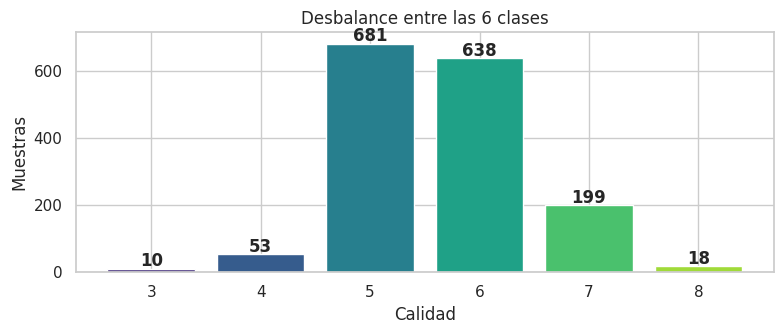


Clases 5 y 6 = 82.5% de los datos; clases 3 y 8 = 1.8%.
Clase 3 tiene solo 2 muestras en test y clase 8 solo 3: sus métricas son muy inestables.


In [31]:
# 12.1  Distribución de las 6 clases y split
y_m = df['quality']
Xm_train, Xm_test, ym_train, ym_test = train_test_split(X, y_m, test_size=0.20, random_state=RANDOM_STATE, stratify=y_m)
CLASES = sorted(y_m.unique())

dist = pd.DataFrame({'Total': y_m.value_counts().sort_index(), 'Train': ym_train.value_counts().sort_index(),
                     'Test': ym_test.value_counts().sort_index()})
dist['% del total'] = (dist['Total'] / dist['Total'].sum() * 100).round(1)
print('Distribución por clase:')
display(dist)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(dist.index.astype(str), dist['Total'], color=sns.color_palette('viridis', 6))
for i, v in enumerate(dist['Total']):
    ax.text(i, v + 8, str(v), ha='center', fontweight='bold')
ax.set_xlabel('Calidad'); ax.set_ylabel('Muestras'); ax.set_title('Desbalance entre las 6 clases')
plt.tight_layout(); plt.show()
print(f'\nClases 5 y 6 = {(dist.loc[[5, 6], "Total"].sum() / len(df)):.1%} de los datos; clases 3 y 8 = {(dist.loc[[3, 8], "Total"].sum() / len(df)):.1%}.')
print(f'Clase 3 tiene solo {dist.loc[3, "Test"]} muestras en test y clase 8 solo {dist.loc[8, "Test"]}: sus métricas son muy inestables.')

In [32]:
# 12.2  Definición de los 4 modelos multiclase
def build_multi(name, balanced):
    cw = 'balanced' if balanced else None
    if name == 'Logistic Regression':
        clf = LogisticRegression(max_iter=2000, class_weight=cw, random_state=RANDOM_STATE)
        return Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    if name == 'Decision Tree':
        return Pipeline([('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, class_weight=cw, random_state=RANDOM_STATE))])
    if name == 'SVM':
        return Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel=best_kernel, class_weight=cw, random_state=RANDOM_STATE))])
    if name == 'KNN':
        return Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=best_k))])

NAMES = ['Logistic Regression', 'Decision Tree', 'SVM', 'KNN']
LABEL = {'Logistic Regression': 'LR', 'Decision Tree': 'DT', 'SVM': f'SVM ({best_kernel})', 'KNN': f'KNN (K={best_k})'}

def evaluate_multi(balanced):
    out, preds, fitted = [], {}, {}
    for n in NAMES:
        if balanced and n == 'KNN':
            continue
        p = build_multi(n, balanced)
        r = cross_validate(p, Xm_train, ym_train, cv=cv, scoring=['accuracy', 'f1_macro', 'f1_weighted'], n_jobs=-1)
        p.fit(Xm_train, ym_train)
        yp = p.predict(Xm_test)
        preds[n], fitted[n] = yp, p
        out.append({'Modelo': LABEL[n],
                    'Accuracy CV': r['test_accuracy'].mean(), 'F1 macro CV': r['test_f1_macro'].mean(),
                    'F1 weighted CV': r['test_f1_weighted'].mean(),
                    'Accuracy test': accuracy_score(ym_test, yp),
                    'F1 micro test': f1_score(ym_test, yp, average='micro'),
                    'F1 macro test': f1_score(ym_test, yp, average='macro', zero_division=0),
                    'F1 weighted test': f1_score(ym_test, yp, average='weighted', zero_division=0),
                    'Bal. accuracy test': balanced_accuracy_score(ym_test, yp)})
    return pd.DataFrame(out).set_index('Modelo'), preds, fitted

res_nat, pred_nat, fit_nat = evaluate_multi(balanced=False)
res_bal, pred_bal, fit_bal = evaluate_multi(balanced=True)
print('=== Multiclase SIN class_weight ===')
display(res_nat.round(4))
print('=== Multiclase CON class_weight="balanced" (KNN no aplica) ===')
display(res_bal.round(4))

=== Multiclase SIN class_weight ===


,Accuracy CV,F1 macro CV,F1 weighted CV,Accuracy test,F1 micro test,F1 macro test,F1 weighted test,Bal. accuracy test
Modelo,,,,,,,,
LR,0.5989,0.3033,0.5763,0.5906,0.5906,0.2776,0.5673,0.2729
DT,0.5919,0.2727,0.5692,0.5812,0.5812,0.2852,0.5634,0.2864
SVM (poly),0.5887,0.2705,0.5572,0.6062,0.6062,0.2883,0.5842,0.2816
KNN (K=1),0.6294,0.3244,0.6246,0.6250,0.6250,0.3762,0.6296,0.4014


=== Multiclase CON class_weight="balanced" (KNN no aplica) ===


,Accuracy CV,F1 macro CV,F1 weighted CV,Accuracy test,F1 micro test,F1 macro test,F1 weighted test,Bal. accuracy test
Modelo,,,,,,,,
LR,0.4402,0.2841,0.4841,0.3969,0.3969,0.2402,0.4408,0.2589
DT,0.3323,0.2224,0.3513,0.3969,0.3969,0.2702,0.4089,0.4503
SVM (poly),0.5574,0.3369,0.5659,0.5688,0.5688,0.3346,0.5837,0.3490


Comparación binario vs multiclase (test, sin class_weight en multiclase):


,Accuracy binario,F1 (clase Bueno) binario,Accuracy multiclase,F1 macro multiclase
LR,0.8125,0.5312,0.5906,0.2776
DT,0.8094,0.5414,0.5812,0.2852
SVM,0.8969,0.6598,0.6062,0.2883
KNN,0.9094,0.6588,0.6250,0.3762



Referencia: predecir siempre la clase mayoritaria (5) da accuracy = 0.425 en multiclase, y 0.866 en binaria (predecir siempre "Estándar").


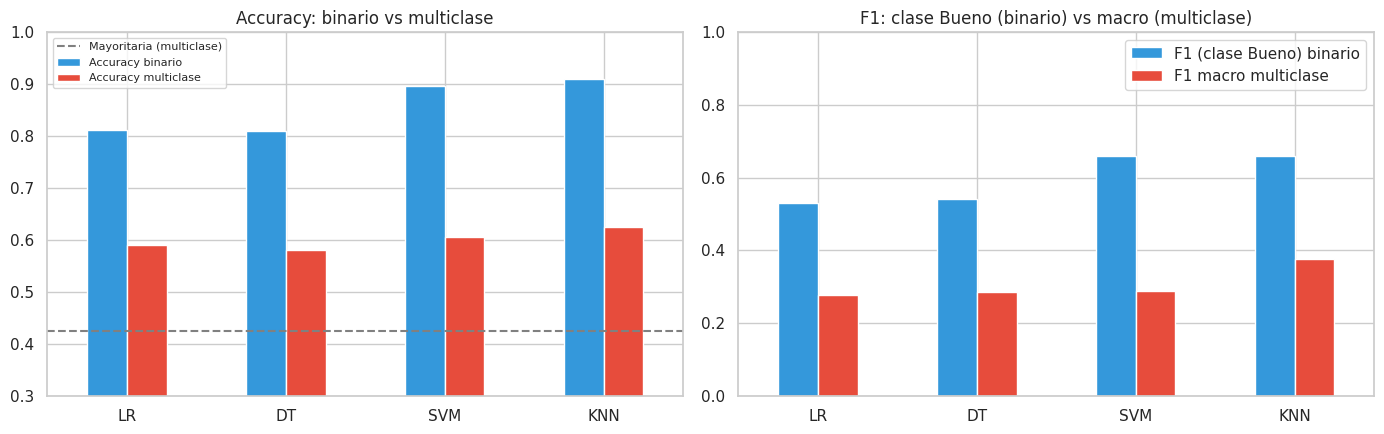

In [33]:
# 12.3  ¿Cómo cambia el rendimiento? Binario (sesión) vs multiclase
bin_acc = {'LR': accuracy_score(y_test, y_pred_lr), 'DT': accuracy_score(y_test, y_pred_dt),
           'SVM': accuracy_score(y_test, y_pred_svm), 'KNN': accuracy_score(y_test, y_pred_knn)}
bin_f1 = {'LR': f1_score(y_test, y_pred_lr), 'DT': f1_score(y_test, y_pred_dt),
          'SVM': f1_score(y_test, y_pred_svm), 'KNN': f1_score(y_test, y_pred_knn)}
chance_multi = ym_test.value_counts(normalize=True).max()

comp = pd.DataFrame({
    'Accuracy binario': bin_acc,
    'F1 (clase Bueno) binario': bin_f1,
    'Accuracy multiclase': dict(zip(['LR', 'DT', 'SVM', 'KNN'], res_nat['Accuracy test'].values)),
    'F1 macro multiclase': dict(zip(['LR', 'DT', 'SVM', 'KNN'], res_nat['F1 macro test'].values)),
})
print('Comparación binario vs multiclase (test, sin class_weight en multiclase):')
display(comp.round(4))
print(f'\nReferencia: predecir siempre la clase mayoritaria (5) da accuracy = {chance_multi:.3f} en multiclase, '
      f'y {1 - y_test.mean():.3f} en binaria (predecir siempre "Estándar").')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
comp[['Accuracy binario', 'Accuracy multiclase']].plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], rot=0)
axes[0].axhline(chance_multi, color='gray', ls='--', label='Mayoritaria (multiclase)'); axes[0].legend(fontsize=8)
axes[0].set_title('Accuracy: binario vs multiclase'); axes[0].set_ylim(0.3, 1)
comp[['F1 (clase Bueno) binario', 'F1 macro multiclase']].plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'], rot=0)
axes[1].set_title('F1: clase Bueno (binario) vs macro (multiclase)'); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

F1 por clase (test):


,LR,DT,SVM (poly),KNN (K=1)
Calidad 3,0.00,0.00,0.00,0.00
Calidad 4,0.00,0.00,0.00,0.16
Calidad 5,0.67,0.66,0.70,0.70
Calidad 6,0.57,0.56,0.57,0.65
Calidad 7,0.42,0.50,0.46,0.53
Calidad 8,0.00,0.00,0.00,0.22


Recall por clase (test):


,LR,DT,SVM (poly),KNN (K=1)
Calidad 3,0.00,0.00,0.00,0.00
Calidad 4,0.00,0.00,0.00,0.18
Calidad 5,0.73,0.71,0.79,0.66
Calidad 6,0.61,0.56,0.57,0.66
Calidad 7,0.30,0.45,0.32,0.57
Calidad 8,0.00,0.00,0.00,0.33


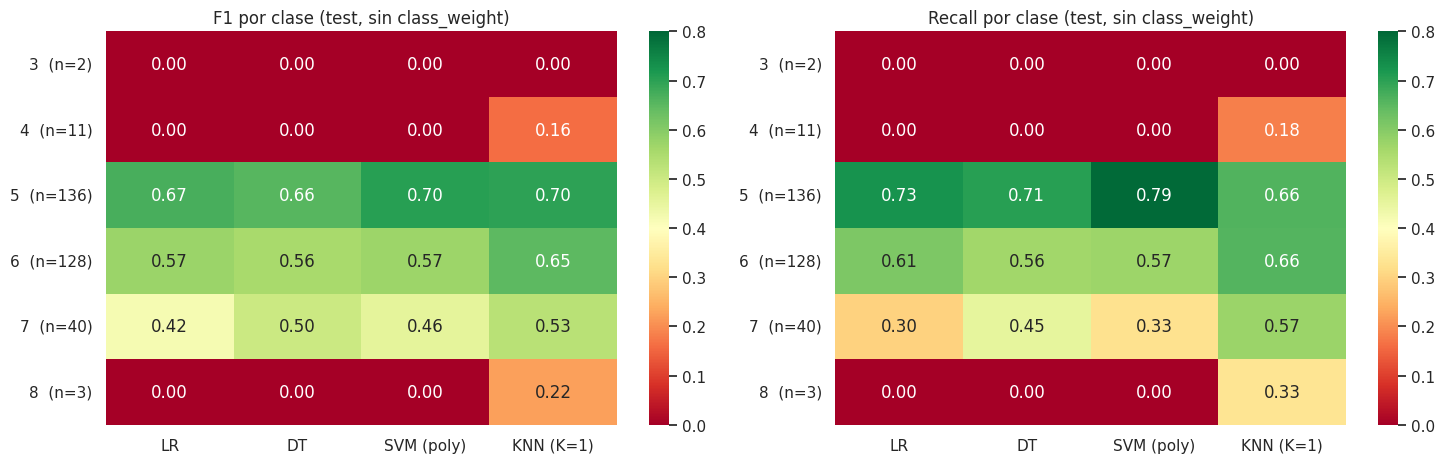

In [34]:
# 12.4  ¿Qué clases son más difíciles? F1 y Recall por clase
def per_class(preds):
    f1s, recs, precs = {}, {}, {}
    for n, yp in preds.items():
        p, r, f, _ = precision_recall_fscore_support(ym_test, yp, labels=CLASES, zero_division=0)
        f1s[LABEL[n]], recs[LABEL[n]], precs[LABEL[n]] = f, r, p
    idx = [f'Calidad {c}' for c in CLASES]
    return pd.DataFrame(f1s, index=idx), pd.DataFrame(recs, index=idx), pd.DataFrame(precs, index=idx)

f1_pc, rec_pc, pre_pc = per_class(pred_nat)
support = ym_test.value_counts().reindex(CLASES).values
print('F1 por clase (test):'); display(f1_pc.round(2))
print('Recall por clase (test):'); display(rec_pc.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
sns.heatmap(f1_pc, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=0.8, ax=axes[0])
axes[0].set_title('F1 por clase (test, sin class_weight)')
sns.heatmap(rec_pc, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=0.8, ax=axes[1])
axes[1].set_title('Recall por clase (test, sin class_weight)')
for ax in axes:
    ax.set_yticklabels([f'{c}  (n={s})' for c, s in zip(CLASES, support)], rotation=0)
plt.tight_layout(); plt.show()

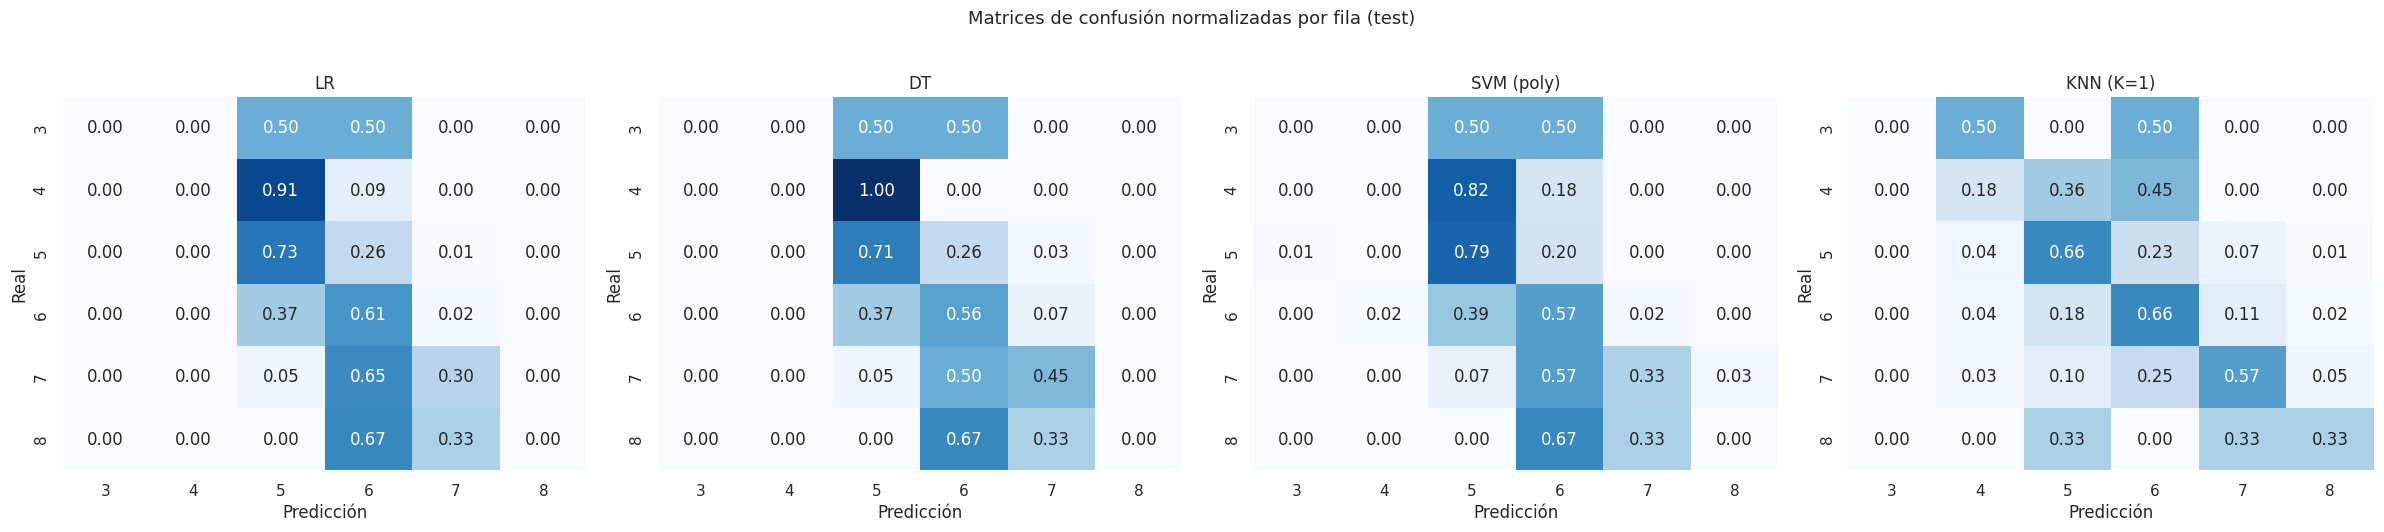

In [35]:
# 12.5  Matrices de confusión normalizadas por fila (recall) — sin class_weight
fig, axes = plt.subplots(1, 4, figsize=(24, 5.2))
for ax, n in zip(axes, NAMES):
    cm = confusion_matrix(ym_test, pred_nat[n], labels=CLASES, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, cbar=False, ax=ax,
                xticklabels=CLASES, yticklabels=CLASES)
    ax.set_title(f'{LABEL[n]}'); ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
fig.suptitle('Matrices de confusión normalizadas por fila (test)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [36]:
# 12.6  Naturaleza del error: la calidad es ORDINAL (los errores suelen ser de ±1)
rows = []
for n in NAMES:
    yp = pred_nat[n]; err = np.abs(yp - ym_test.values)
    rows.append({'Modelo': LABEL[n], 'Exactas': (err == 0).mean(), 'Error ±1': (err == 1).mean(),
                 'Error ≥2': (err >= 2).mean(), 'Acierto tolerando ±1': (err <= 1).mean(), 'MAE (niveles)': err.mean()})
ordinal = pd.DataFrame(rows).set_index('Modelo')
print('Distribución del error de predicción (test):')
display(ordinal.round(3).style.format('{:.3f}'))

Distribución del error de predicción (test):


,Exactas,Error ±1,Error ≥2,Acierto tolerando ±1,MAE (niveles)
Modelo,,,,,
LR,0.591,0.384,0.025,0.975,0.438
DT,0.581,0.388,0.031,0.969,0.453
SVM (poly),0.606,0.356,0.038,0.962,0.434
KNN (K=1),0.625,0.284,0.091,0.909,0.478


F1 según el promedio elegido (test, sin class_weight):


,F1 micro test,F1 weighted test,F1 macro test,Accuracy test
Modelo,,,,
LR,0.5906,0.5673,0.2776,0.5906
DT,0.5812,0.5634,0.2852,0.5812
SVM (poly),0.6062,0.5842,0.2883,0.6062
KNN (K=1),0.6250,0.6296,0.3762,0.6250


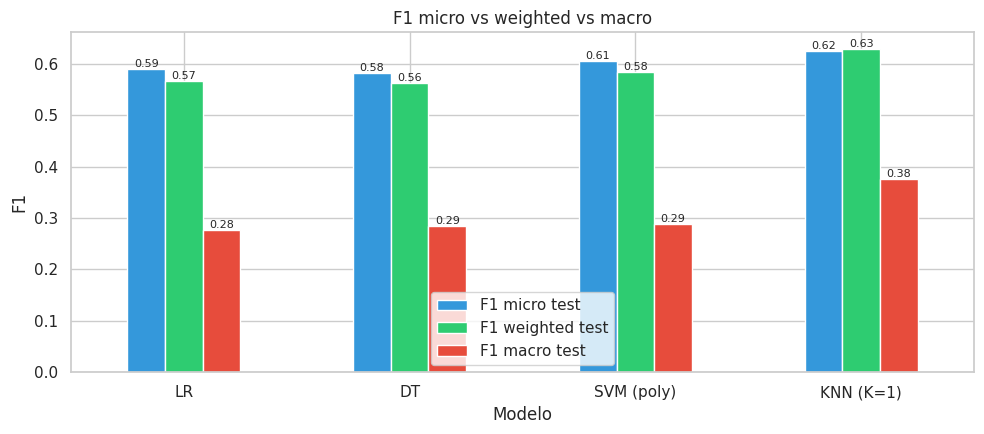


F1 micro ≡ Accuracy (comprobado en la tabla).
macro pondera igual a las 6 clases → penaliza fallar en las minoritarias (3, 4, 8).
weighted pondera por soporte → casi coincide con el desempeño en las clases 5 y 6.


In [37]:
# 12.7  ¿macro, micro o weighted? Mismo modelo, tres visiones
show = res_nat[['F1 micro test', 'F1 weighted test', 'F1 macro test']].copy()
show['Accuracy test'] = res_nat['Accuracy test']
print('F1 según el promedio elegido (test, sin class_weight):')
display(show.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5))
show[['F1 micro test', 'F1 weighted test', 'F1 macro test']].plot(kind='bar', ax=ax, rot=0,
                                                                 color=['#3498db', '#2ecc71', '#e74c3c'])
ax.set_ylabel('F1'); ax.set_title('F1 micro vs weighted vs macro')
for cont in ax.containers:
    ax.bar_label(cont, fmt='%.2f', fontsize=8)
plt.tight_layout(); plt.show()
print('\nF1 micro ≡ Accuracy (comprobado en la tabla).')
print('macro pondera igual a las 6 clases → penaliza fallar en las minoritarias (3, 4, 8).')
print('weighted pondera por soporte → casi coincide con el desempeño en las clases 5 y 6.')

In [38]:
# 12.8  Efecto de class_weight="balanced" en multiclase
rows = []
for n in ['Logistic Regression', 'Decision Tree', 'SVM']:
    for tag, r in [('sin', res_nat), ('balanced', res_bal)]:
        rows.append({'Modelo': LABEL[n], 'class_weight': tag,
                     'Accuracy': r.loc[LABEL[n], 'Accuracy test'], 'F1 macro': r.loc[LABEL[n], 'F1 macro test'],
                     'F1 weighted': r.loc[LABEL[n], 'F1 weighted test'],
                     'Bal. accuracy': r.loc[LABEL[n], 'Bal. accuracy test']})
cw = pd.DataFrame(rows).set_index(['Modelo', 'class_weight'])
display(cw.round(4))

# Recall de las clases minoritarias con y sin ponderación
rec_bal = per_class(pred_bal)[1]
mini = pd.concat({'sin class_weight': rec_pc.loc[['Calidad 3', 'Calidad 4', 'Calidad 8']].drop(columns=[LABEL['KNN']]),
                  'balanced': rec_bal.loc[['Calidad 3', 'Calidad 4', 'Calidad 8']]}, axis=1)
print('\nRecall en clases minoritarias:')
display(mini.round(2))

Accuracy  F1 macro  F1 weighted  Bal. accuracy
Modelo     class_weight                                                
LR         sin             0.5906    0.2776       0.5673         0.2729
           balanced        0.3969    0.2402       0.4408         0.2589
DT         sin             0.5812    0.2852       0.5634         0.2864
           balanced        0.3969    0.2702       0.4089         0.4503
SVM (poly) sin             0.6062    0.2883       0.5842         0.2816
           balanced        0.5688    0.3346       0.5837         0.3490


Recall en clases minoritarias:


sin class_weight                 balanced                 
                        LR   DT SVM (poly)       LR    DT SVM (poly)
Calidad 3              0.0  0.0        0.0     0.00  0.50       0.00
Calidad 4              0.0  0.0        0.0     0.27  0.36       0.36
Calidad 8              0.0  0.0        0.0     0.00  0.67       0.00

In [39]:
# 12.9  Verificación de calidad de datos: filas duplicadas y posible fuga entre train y test
n_dup = df[list(features) + ['quality']].duplicated().sum()
dup_mask = Xm_test.merge(Xm_train.drop_duplicates(), how='left', indicator=True)['_merge'].eq('both').values
print(f'Filas duplicadas en el dataset: {n_dup} de {len(df)} ({n_dup / len(df):.1%})')
print(f'Filas de test con un duplicado exacto en train: {dup_mask.sum()} de {len(dup_mask)} ({dup_mask.mean():.1%})\n')

rows = []
for n in NAMES:
    yp = pred_nat[n]; ok = (yp == ym_test.values)
    rows.append({'Modelo': LABEL[n], 'Accuracy test con duplicado en train': ok[dup_mask].mean(),
                 'Accuracy test SIN duplicado en train': ok[~dup_mask].mean()})
dupdf = pd.DataFrame(rows).set_index('Modelo')
dupdf['Diferencia (pts)'] = (dupdf.iloc[:, 0] - dupdf.iloc[:, 1]) * 100
display(dupdf.round(3))
print('\n→ Si un modelo acierta mucho más en las filas repetidas, está memorizando en lugar de generalizar.')
print('  Esto infla especialmente a KNN con K pequeño (la sesión elige K=1 por F1 en CV, y la CV también tiene duplicados entre folds).')

Filas duplicadas en el dataset: 240 de 1599 (15.0%)
Filas de test con un duplicado exacto en train: 76 de 320 (23.8%)



,Accuracy test con duplicado en train,Accuracy test SIN duplicado en train,Diferencia (pts)
Modelo,,,
LR,0.684,0.561,12.274
DT,0.658,0.557,10.052
SVM (poly),0.750,0.561,18.852
KNN (K=1),1.000,0.508,49.180



→ Si un modelo acierta mucho más en las filas repetidas, está memorizando en lugar de generalizar.
  Esto infla especialmente a KNN con K pequeño (la sesión elige K=1 por F1 en CV, y la CV también tiene duplicados entre folds).


### Análisis del Ejercicio 2

#### 1) ¿Cómo cambia el rendimiento de cada modelo?

| Modelo | Accuracy binario | Accuracy multiclase | F1 macro multiclase |
|---|---|---|---|
| Reg. Logística | 0.812 | 0.591 | 0.278 |
| Árbol de Decisión | 0.809 | 0.581 | 0.285 |
| SVM (poly) | 0.897 | 0.606 | 0.288 |
| KNN (K = 1) | 0.909 | 0.625 | 0.376 |

- La accuracy baja de ≈ 0.81–0.91 a ≈ 0.58–0.63, pero **no es comparable directamente**: el punto de partida también cambia. Predecir siempre la clase mayoritaria da 0.866 en binaria y solo **0.425** en multiclase. En multiclase todos los modelos superan esa referencia por **16–20 puntos**; en binaria, LR y DT quedan por debajo de ella (efecto de `class_weight='balanced'`).
- El **F1 macro (0.28–0.38) es mucho menor que el accuracy** porque hay clases en las que los modelos no aciertan nada (ver punto 2).
- Sin ponderación, los tres modelos paramétricos (LR, DT, SVM) rinden casi igual (accuracy 0.58–0.61, diferencias dentro del ruido).

#### 2) ¿Qué clases son más difíciles de distinguir?

- **Las clases 3, 4 y 8 son prácticamente imposibles:** F1 = 0 y Recall = 0 en LR, DT y SVM. Tienen 2, 11 y 3 muestras en test (0.6 %, 3.3 % y 1.1 % del total): los modelos aprenden a ignorarlas porque equivocarse allí casi no cuesta accuracy.
- **Las mejores son 5 y 6** (F1 0.56–0.70), que concentran el 82.5 % de los datos. La **clase 7** queda en un nivel intermedio (F1 0.42–0.53; Recall 0.30–0.57).
- **La confusión es entre categorías vecinas:** en LR, DT y SVM entre el **96 % y el 98 % de las predicciones** caen a lo sumo a un nivel del valor real (5↔6 y 6↔7 sobre todo). La calidad es una variable **ordinal**, y los vinos "casi iguales" físico-químicamente reciben notas adyacentes. Tratarla como nominal desperdicia esa estructura; una regresión o un modelo ordinal serían alternativas naturales.

#### 3) Precaución: el aparente mejor modelo (KNN) memoriza

KNN con K = 1 parece el mejor (accuracy 0.625, F1 macro 0.376, único con Recall > 0 en las clases 4 y 8). Pero la sección 12.9 muestra que **acierta el 100 % de las filas de test que tienen un duplicado exacto en train (≈ 24 % del test) y solo el 50.8 % del resto**, la peor cifra de los cuatro (LR 0.56, DT 0.56, SVM 0.56). Además, comete errores de dos o más niveles en el 9.1 % de los casos (2.5–3.8 % en los demás). **En datos realmente nuevos KNN (K = 1) es el peor modelo**; su ventaja es un artefacto de los duplicados. Todos los modelos aciertan más en filas repetidas (SVM 0.75 vs 0.56), así que las métricas del dataset están algo infladas.

#### 4) ¿Qué F1 es más adecuado: macro, micro o weighted?

| Promedio | Qué mide | Aquí |
|---|---|---|
| **micro** | Cuenta todos los aciertos por igual → **equivale exactamente a la accuracy** (comprobado en la tabla) | Lo dominan las clases 5 y 6 (82.5 %); oculta que las demás fallan |
| **weighted** | Promedia el F1 por clase ponderado por su frecuencia | Casi idéntico a lo que ocurre en 5 y 6 (0.56–0.63) |
| **macro** | Promedia el F1 de las 6 clases con el mismo peso | Expone el fracaso en las clases raras (0.28–0.38) |

**Recomendación: F1 macro como métrica principal**, acompañada del F1 por clase. Justificación: (i) el desbalance es fuerte (43 % / 40 % vs 0.6 %) y micro/weighted lo enmascaran, (ii) en un problema de calidad interesa distinguir también los vinos extremos (muy malos o excelentes), que son las clases raras. **Salvedades:** macro es **muy ruidoso** aquí porque tres clases tienen entre 2 y 11 muestras en test (un solo acierto cambia el F1 de esa clase de 0 a 0.5) y no distingue un error de un nivel de uno de cinco. Por eso conviene reportar también la **accuracy tolerando ±1** y el error medio en niveles (MAE ≈ 0.43–0.48). Si el objetivo fuera el rendimiento sobre la distribución natural de vinos, sería preferible *weighted*.

#### 5) Efecto de `class_weight='balanced'` en multiclase

| Modelo | Accuracy (sin → con) | F1 macro (sin → con) | Balanced accuracy (sin → con) |
|---|---|---|---|
| Reg. Logística | 0.591 → 0.397 | 0.278 → 0.240 | 0.273 → 0.259 |
| Árbol de Decisión | 0.581 → 0.397 | 0.285 → 0.270 | 0.286 → 0.450 |
| SVM (poly) | 0.606 → 0.569 | 0.288 → **0.335** | 0.282 → 0.349 |

- La ponderación **hace que las clases raras dejen de ignorarse** (p. ej. Recall de la clase 4: 0 → 0.27 en LR y 0.36 en DT/SVM), pero el precio en accuracy es alto, sobre todo en LR y DT (−19 puntos).
- **Solo mejora el F1 macro en la SVM** (+4.7 puntos); en LR y DT baja, pese a que el Árbol gana en balanced accuracy. Los Recall de las clases 3 y 8 (0.50 y 0.67 en el Árbol) provienen de 1 y 2 aciertos sobre 2 y 3 muestras: **no son evidencia sólida**.

---
## 13. Conclusiones

- **Ejercicio 1:** el `GridSearchCV` (rbf, C = 10, gamma = 0.1) mejora el F1 en CV solo +0.95 puntos y **empeora el F1 en test (−1.8)**; la mejora no es consistente entre folds. Sí mueve el punto de operación (más Recall, más falsas alarmas, mejor AUC). La grilla contiene parámetros redundantes ('scale' = 'auto'; el producto C·γ³ en poly) y el límite del rendimiento está en los datos, no en los hiperparámetros.
- **Ejercicio 2:** al pasar a 6 clases, la accuracy cae a 0.58–0.63 (pero sobre una base de 0.425) y el F1 macro a 0.28–0.38. **Las clases 3, 4 y 8 no se aprenden** (muy pocas muestras) y casi todos los errores son de un solo nivel, lo que indica que el problema es **ordinal**. **F1 macro** es la métrica más informativa, con las salvedades de ruido descritas.
- **Calidad de datos:** el 15 % de las filas están duplicadas y ≈ 24 % del test tiene copia en train; esto **infla los resultados de KNN con K = 1** (100 % en filas repetidas, 51 % en el resto) y, en menor medida, de los demás. Una práctica más rigurosa sería eliminar duplicados antes de dividir los datos.
- **Cierre:** ninguna configuración es claramente superior a las demás con estos datos: las diferencias entre modelos quedan dentro del ruido de la validación cruzada.